# PI10102 — Δ-space fault prognosis plots

Visual sanity check for the per-file Δ-space alarm pipeline
(`scripts/adaptation/full_shot/PI10102/perfile_rate/`). Mirrors
`figures/PI10102/plot_fault_prognosis.ipynb` but every prediction and target
is converted to Δ space before plotting, and the alarm hlines are the
**per-file** ±τ from `setting/limits_zjsh_pi10102ts_perfile_rate.csv`
(loaded from `figures/PI10102/diff/limits_perfile.csv` for traceability).

Δ-space conversion (matches `batch_metrics_perfile_rate.py`):
```
Δpred[w, 0] = pred[w, 0] - true_series[window_starts[w] - 1]
Δpred[w, t] = pred[w, t] - pred[w, t-1]   (t ≥ 1)
```
(same formula on truth → Δtrue).

## 1. Setup and limits

Loads the same `batch_metrics_zjsh_pi10102ts.yaml` so the model entries and test
files line up exactly with the metrics pipeline.

In [1]:
import numpy as np
import pandas as pd
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# notebook is at figures/PI10102/diff/, TSFM root is 3 levels up
TSFM_ROOT = Path('../../..')
cfg_path = TSFM_ROOT / 'setting' / 'batch_metrics_zjsh_pi10102ts.yaml'
cfg = yaml.safe_load(cfg_path.read_text())
params = cfg.get('params', {})

target          = params['target']
eval_steps      = int(params.get('eval_steps', 15))
data_root       = Path(params['data_root'])
results_root    = TSFM_ROOT / params.get('results_root', './results')
align_cfg       = params.get('align_eval_to') or {}
align_seq_len   = int(align_cfg['seq_len'])
align_pred_len  = int(align_cfg['pred_len'])

model_entries = {entry['name']: entry for entry in cfg['model_dirs']}
test_files = cfg['test']

# Per-file Δ-space alarm limits — written by build_limits.py and copied here
limits_path = Path('./limits_perfile.csv')
if not limits_path.exists():
    limits_path = TSFM_ROOT / 'setting' / 'limits_zjsh_pi10102ts_perfile_rate.csv'
limits_df = pd.read_csv(limits_path).set_index('filename')
limits_df = limits_df.loc[test_files]
H_per_file = limits_df['H'].to_numpy(dtype=float)
L_per_file = limits_df['L'].to_numpy(dtype=float)
tau_per_file = np.maximum(H_per_file, -L_per_file)

print(f'target={target}  eval_steps={eval_steps}  align=({align_seq_len},{align_pred_len})')
print('per-file ±τ:')
for i, name in enumerate(test_files):
    print(f'  [{i}] {name}: H=+{H_per_file[i]:.4f}  L={L_per_file[i]:.4f}  τ={tau_per_file[i]:.4f}')

target=PI10102  eval_steps=15  align=(768,96)
per-file ±τ:
  [0] 2103ts/PI10102_transition_020_c17_to_c5_len904.csv: H=+0.0026  L=-0.0026  τ=0.0026
  [1] 2103ts/PI10102_transition_021_c5_to_c16_len3625.csv: H=+1.0896  L=-1.0896  τ=1.0896
  [2] 2103ts/PI10102_transition_022_c16_to_c14_len1475.csv: H=+1.0800  L=-1.0800  τ=1.0800
  [3] 2103ts/PI10102_transition_023_c14_to_c15_len1134.csv: H=+1.0322  L=-1.0322  τ=1.0322


## 2. Build concatenated true series and Δtrue

In [23]:
test_files = test_files[1:]

In [24]:
true_series_per_file = []
file_lengths = []
for name in test_files:
    df = pd.read_csv(data_root / name)
    arr = df[target].to_numpy(copy=True).astype(np.float64)
    true_series_per_file.append(arr)
    file_lengths.append(len(arr))
true_series = np.concatenate(true_series_per_file, axis=0)
file_offsets = np.cumsum([0] + file_lengths)

# Δtrue over the raw series, reset at each file boundary
diff_series = np.zeros_like(true_series, dtype=np.float64)
for f, L in enumerate(file_lengths):
    a, b = file_offsets[f], file_offsets[f] + L
    diff_series[a] = 0.0
    diff_series[a+1:b] = np.diff(true_series[a:b])

print(f'true_series len = {len(true_series)},  files = {file_lengths}')
print('per-file Δ stats:')
for f in range(len(file_lengths)):
    seg = diff_series[file_offsets[f]:file_offsets[f+1]]
    print(f'  file {f}  min={seg.min():.4f}  max={seg.max():.4f}  '
          f'std={seg.std():.4f}  q95|Δ|={np.quantile(np.abs(seg),0.95):.4f}  '
          f'τ_file=±{tau_per_file[f]:.4f}')

true_series len = 6234,  files = [3625, 1475, 1134]
per-file Δ stats:
  file 0  min=-2.0644  max=2.1027  std=0.5579  q95|Δ|=1.0896  τ_file=±0.0026
  file 1  min=-2.2269  max=1.7967  std=0.5590  q95|Δ|=1.0800  τ_file=±1.0896
  file 2  min=-1.5483  max=1.7680  std=0.5307  q95|Δ|=1.0322  τ_file=±1.0800


/tmp/ipykernel_456494/281125317.py:36: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig('a_concat_diff_series.png', dpi=300, bbox_inches='tight')
/home/aicode/miniconda3/envs/tsfm/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


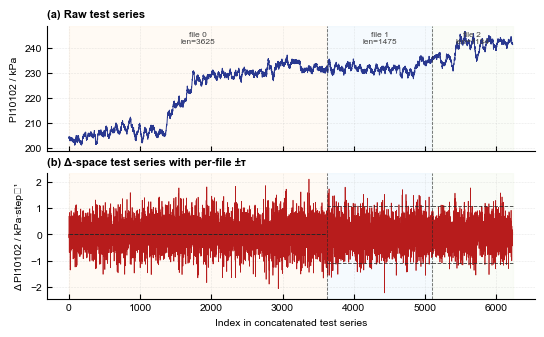

In [25]:
# Two-panel overview: raw series (top) and Δ series (bottom) with per-file ±τ.
seg_colors = ['#FFF3E0', '#E3F2FD', '#F1F8E9', '#FCE4EC']
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16/2.54, 9/2.54), sharex=True,
                                gridspec_kw={'hspace': 0.18})
x = np.arange(len(true_series))

ax1.plot(x, true_series, color='#293890', linewidth=0.7)
for f in range(len(file_lengths)):
    lo, hi = file_offsets[f], file_offsets[f+1]
    ax1.axvspan(lo, hi, color=seg_colors[f % len(seg_colors)], alpha=0.35, zorder=0)
    if f > 0:
        ax1.axvline(lo, color='#262626', linewidth=0.6, linestyle='--', alpha=0.7)
    ax1.text((lo + hi) / 2, np.nanmax(true_series),
             f'file {f}\nlen={hi-lo}', ha='center', va='top', fontsize=6,
             color='#424242')
ax1.set_ylabel('PI10102 / kPa')
ax1.set_title('(a) Raw test series', loc='left', fontsize=8, fontweight='bold')
ax1.grid(True, linewidth=0.4, alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

ax2.plot(x, diff_series, color='#B71C1C', linewidth=0.5)
for f in range(len(file_lengths)):
    lo, hi = file_offsets[f], file_offsets[f+1]
    ax2.axvspan(lo, hi, color=seg_colors[f % len(seg_colors)], alpha=0.35, zorder=0)
    if f > 0:
        ax2.axvline(lo, color='#262626', linewidth=0.6, linestyle='--', alpha=0.7)
    ax2.hlines([H_per_file[f], L_per_file[f]], lo, hi,
               colors='#262626', linewidth=0.7, linestyle='--', alpha=0.8)
ax2.set_xlabel('Index in concatenated test series')
ax2.set_ylabel('Δ PI10102 / kPa·step⁻¹')
ax2.set_title('(b) Δ-space test series with per-file ±τ', loc='left',
              fontsize=8, fontweight='bold')
ax2.grid(True, linewidth=0.4, alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.savefig('a_concat_diff_series.png', dpi=300, bbox_inches='tight')
plt.show()

per-file thresholds (q=0.95):
  file 0: τ_Δ1=±0.003  τ_Δ15=±2.968  τ_slope·H=±3.222  τ_CUSUM=±0.000  τ_k(1,5,15)=[1.09, 1.673, 2.968]
  file 1: τ_Δ1=±1.090  τ_Δ15=±2.466  τ_slope·H=±2.639  τ_CUSUM=±0.000  τ_k(1,5,15)=[1.08, 1.625, 2.466]
  file 2: τ_Δ1=±1.080  τ_Δ15=±3.623  τ_slope·H=±3.807  τ_CUSUM=±0.000  τ_k(1,5,15)=[1.032, 1.881, 3.623]


/tmp/ipykernel_456494/16654545.py:127: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig('a_trend_indicators_panel.png', dpi=300, bbox_inches='tight')
/home/aicode/miniconda3/envs/tsfm/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


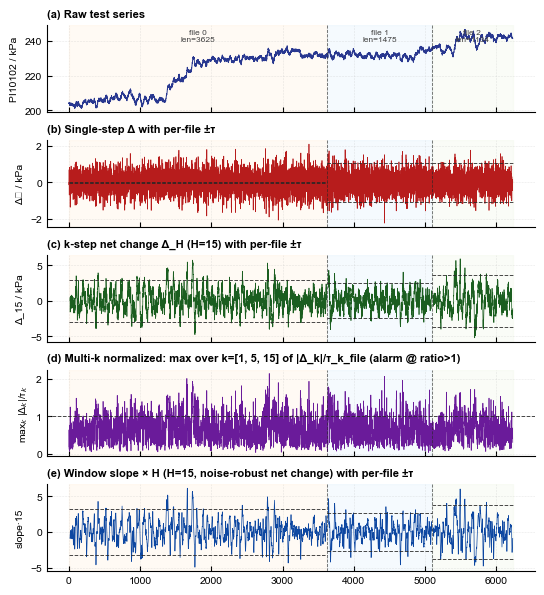

In [28]:
# Six-panel overview: (a) raw, (b) Δ₁, (c) Δ_H net change, (d) multi-k normalized max,              
# (e) window slope × H, (f) CUSUM ±. Threshold philosophy unchanged: per-file 0.95 quantile.        
seg_colors = ['#FFF3E0', '#E3F2FD', '#F1F8E9', '#FCE4EC']                                           
H = eval_steps                 # 15-step horizon                                                    
k_list = [1, 5, 15]                                                                                 
cusum_k_factor = 0.5           # CUSUM slack in σ units                                             
q = 0.95                                               
                                                                                                    
# --- precompute trend indicators, NaN-padded, reset at every file boundary ---                     
delta_H        = np.full(len(true_series), np.nan)
delta_max_norm = np.full(len(true_series), np.nan)                                                  
slope_proj     = np.full(len(true_series), np.nan)                                                  
cusum_pos      = np.full(len(true_series), np.nan)
cusum_neg      = np.full(len(true_series), np.nan)                                                  
                                                        
tau_H     = np.zeros(len(file_lengths))                                                             
tau_slope = np.zeros(len(file_lengths))                
tau_cusum = np.zeros(len(file_lengths))                                                             
tau_k     = np.zeros((len(file_lengths), len(k_list)))
                                                                                                    
x_loc  = np.arange(H, dtype=np.float64)                                                             
x_cent = x_loc - x_loc.mean()
ssx    = (x_cent ** 2).sum()                                                                        
                                                        
for f, L in enumerate(file_lengths):                                                                
    a, b = file_offsets[f], file_offsets[f] + L
    seg = true_series[a:b].astype(np.float64)                                                       
                                                        
    # (c) k-step net change at horizon H                                                            
    if L > H:
        d = seg[H:] - seg[:-H]                                                                      
        delta_H[a + H:b] = d                           
        tau_H[f] = float(np.quantile(np.abs(d), q))
                                                                                                    
    # (d) multi-k OR: max over k of |Δ_k|/τ_k_file; threshold becomes 1.0                           
    norm_local = np.full(L, np.nan)                                                                 
    for j, k in enumerate(k_list):                                                                  
        if L > k:                                      
            dk_abs = np.abs(seg[k:] - seg[:-k])                                                     
            tau_k[f, j] = float(np.quantile(dk_abs, q))
            if tau_k[f, j] > 0:                                                                     
                slot = np.full(L, np.nan)                                                           
                slot[k:] = dk_abs / tau_k[f, j]
                norm_local = np.fmax(norm_local, slot)                                              
    delta_max_norm[a:b] = norm_local                                                                

    # (e) rolling-window linear slope × H (noise-robust net change)                                 
    if L >= H:                                         
        slopes = np.full(L, np.nan)                                                                 
        for t in range(H - 1, L):                      
            y = seg[t - H + 1: t + 1]
            slopes[t] = (x_cent * y).sum() / ssx
        proj = slopes * H                                                                           
        slope_proj[a:b] = proj
        tau_slope[f] = float(np.nanquantile(np.abs(proj), q))                                       
                                                                                                    
print('per-file thresholds (q=0.95):')                 
for f in range(len(file_lengths)):                                                                  
    print(f'  file {f}: τ_Δ1=±{tau_per_file[f]:.3f}  τ_Δ{H}=±{tau_H[f]:.3f}  '
        f'τ_slope·H=±{tau_slope[f]:.3f}  τ_CUSUM=±{tau_cusum[f]:.3f}  '                           
        f'τ_k(1,5,15)={np.round(tau_k[f], 3).tolist()}')                                          
                                                                                                    
# --- plotting ---                                                                                  
fig, axes = plt.subplots(5, 1, figsize=(16/2.54, 18/2.54), sharex=True,                             
                        gridspec_kw={'hspace': 0.32})                                             
ax1, ax2, ax3, ax4, ax5= axes
x = np.arange(len(true_series))                                                                     
                                                        
def _shade_files(ax):                                                                               
    for f in range(len(file_lengths)):                 
        lo, hi = file_offsets[f], file_offsets[f+1]
        ax.axvspan(lo, hi, color=seg_colors[f % len(seg_colors)], alpha=0.35, zorder=0)             
        if f > 0:                                                                                   
            ax.axvline(lo, color='#262626', linewidth=0.6, linestyle='--', alpha=0.7)               
                                                                                                    
def _hlines_per_file(ax, hi_arr, lo_arr):                                                           
    for f in range(len(file_lengths)):
        a, b = file_offsets[f], file_offsets[f+1]                                                   
        ax.hlines([hi_arr[f], lo_arr[f]], a, b,        
                colors='#262626', linewidth=0.7, linestyle='--', alpha=0.85)                      

# (a) Raw                                                                                           
ax1.plot(x, true_series, color='#293890', linewidth=0.7)
_shade_files(ax1)                                                                                   
for f in range(len(file_lengths)):                     
    lo, hi = file_offsets[f], file_offsets[f+1]
    ax1.text((lo + hi) / 2, np.nanmax(true_series),                                                 
            f'file {f}\nlen={hi-lo}', ha='center', va='top', fontsize=6, color='#424242')
ax1.set_ylabel('PI10102 / kPa')                                                                     
ax1.set_title('(a) Raw test series', loc='left', fontsize=8, fontweight='bold')
                                                                                                    
# (b) Single-step Δ                                    
ax2.plot(x, diff_series, color='#B71C1C', linewidth=0.5)                                            
_shade_files(ax2)                                                                                   
_hlines_per_file(ax2, H_per_file, L_per_file)
ax2.set_ylabel('Δ₁ / kPa')                                                                          
ax2.set_title('(b) Single-step Δ with per-file ±τ', loc='left', fontsize=8, fontweight='bold')      

# (c) k-step net change at horizon H                                                                
ax3.plot(x, delta_H, color='#1B5E20', linewidth=0.5)   
_shade_files(ax3)                                                                                   
_hlines_per_file(ax3, tau_H, -tau_H)                   
ax3.set_ylabel(f'Δ_{H} / kPa')                                                                      
ax3.set_title(f'(c) k-step net change Δ_H (H={H}) with per-file ±τ',
            loc='left', fontsize=8, fontweight='bold')                                            
                                                        
# (d) Multi-k OR                                                                                    
ax4.plot(x, delta_max_norm, color='#6A1B9A', linewidth=0.5)
_shade_files(ax4)                                                                                   
ax4.axhline(1.0, color='#262626', linewidth=0.7, linestyle='--', alpha=0.85)
ax4.set_ylabel(r'max$_k$ |Δ$_k$|/τ$_k$')                                                            
ax4.set_title(f'(d) Multi-k normalized: max over k={k_list} of |Δ_k|/τ_k_file (alarm @ ratio>1)',   
            loc='left', fontsize=8, fontweight='bold')                                            
                                                                                                    
# (e) Rolling-slope projected change                                                                
ax5.plot(x, slope_proj, color='#0D47A1', linewidth=0.5)
_shade_files(ax5)                                                                                   
_hlines_per_file(ax5, tau_slope, -tau_slope)
ax5.set_ylabel(f'slope·{H}')                                                                        
ax5.set_title(f'(e) Window slope × H (H={H}, noise-robust net change) with per-file ±τ',            
            loc='left', fontsize=8, fontweight='bold')
                                                                                                    
for ax in axes:                                                                                     
    ax.grid(True, linewidth=0.4, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)                      

plt.savefig('a_trend_indicators_panel.png', dpi=300, bbox_inches='tight')                           
plt.show()     

## 3. Aligned-window indexing and Δ-space loader

In [4]:
def build_window_starts(seq_len, pred_len, file_lengths):
    usable = [max(0, L - seq_len - pred_len + 1) for L in file_lengths]
    cum = np.cumsum([0] + usable)
    offsets = np.cumsum([0] + file_lengths)
    starts = np.zeros(cum[-1], dtype=np.int64)
    file_idx = np.zeros(cum[-1], dtype=np.int64)
    for gi in range(cum[-1]):
        f = int(np.searchsorted(cum[1:], gi, side='right'))
        starts[gi] = offsets[f] + (gi - cum[f]) + seq_len
        file_idx[gi] = f
    return starts, file_idx


def align_window_mask(window_starts, file_idx_arr, file_lengths, asl, apl):
    offsets = np.cumsum([0] + list(file_lengths))
    file_off = offsets[file_idx_arr]
    file_len = np.array(file_lengths, dtype=np.int64)[file_idx_arr]
    return (window_starts >= file_off + asl) & (window_starts <= file_off + file_len - apl)


# All aligned bookkeeping uses the (asl, apl) cut, identical across models
ws_full, fi_full = build_window_starts(align_seq_len, align_pred_len, file_lengths)
keep_full = align_window_mask(ws_full, fi_full, file_lengths, align_seq_len, align_pred_len)
window_starts_aligned = ws_full[keep_full]
file_idx_aligned       = fi_full[keep_full]
N_aligned              = window_starts_aligned.shape[0]

file_segs = {}
for f in range(len(file_lengths)):
    in_f = np.where(file_idx_aligned == f)[0]
    if in_f.size:
        file_segs[f] = (int(in_f[0]), int(in_f[-1]))
print(f'aligned windows: {N_aligned}')
for f, (lo, hi) in file_segs.items():
    print(f'  file {f}  patch_idx=[{lo}, {hi}]  ({hi-lo+1} windows)  τ=±{tau_per_file[f]:.4f}')

aligned windows: 3686
  file 0  patch_idx=[0, 40]  (41 windows)  τ=±0.0026
  file 1  patch_idx=[41, 2802]  (2762 windows)  τ=±1.0896
  file 2  patch_idx=[2803, 3414]  (612 windows)  τ=±1.0800
  file 3  patch_idx=[3415, 3685]  (271 windows)  τ=±1.0322


In [5]:
# Per-window last-input reference value (used for Δpred[:, 0])
last_input_aligned = true_series[window_starts_aligned - 1].astype(np.float64)


def _raw_to_diff(arr_t):
    """Convert aligned (N_aligned, eval_steps) raw forecast/target to Δ space."""
    d = np.empty_like(arr_t, dtype=np.float64)
    d[:, 0]  = arr_t[:, 0] - last_input_aligned
    d[:, 1:] = np.diff(arr_t, axis=1)
    return d


def _load_npy_aligned(name, kind):
    entry = model_entries.get(name)
    if entry is None:
        print(f'WARN: {name} not in yaml')
        return None
    p = results_root / entry['result_dir'] / f'{kind}.npy'
    if not p.exists():
        print(f'MISS: {name} ({p})')
        return None
    arr = np.load(p)
    if arr.ndim == 3:
        arr = arr[:, :, -1]
    sl = int(entry['seq_len']); pl = int(entry['pred_len'])
    ws, fi = build_window_starts(sl, pl, file_lengths)
    if arr.shape[0] != ws.shape[0]:
        print(f'WARN: {name} {kind}: {arr.shape[0]} rows but expected {ws.shape[0]}')
        return None
    keep = align_window_mask(ws, fi, file_lengths, align_seq_len, align_pred_len)
    return arr[keep][:, :eval_steps]


def load_pred_diff(name):
    raw = _load_npy_aligned(name, 'pred')
    return None if raw is None else _raw_to_diff(raw)


def load_true_diff(name):
    raw = _load_npy_aligned(name, 'true')
    return None if raw is None else _raw_to_diff(raw)

## 4. Load all model Δ predictions

Includes:
- Raw forecasters converted to Δ (Timer-XL-MS, Timer-XL-Partial15-MS, CNNLSTM-MS, TimeXer-MS, GTProger-MS, GTProgerV13-MS)
- DIFF Timer-XL family (full-shot / partial15, + p1/p3/p5 ablations)
- Gate-ensemble fusions (T1/T2/T3)

Missing pred/true entries (e.g. baseline-DIFF dirs that haven't been run) are skipped with a warning.

In [6]:
MODEL_NAMES = [
    # Raw forecasters (converted to Δ space here for comparison)
    'Timer-XL-MS', 'Timer-XL-Partial15-MS',
    'CNNLSTM-MS', 'TimeXer-MS', 'GTProger-MS', 'GTProgerV13-MS',
    # DIFF-restored Timer-XL
    'Timer-XL-MS-DIFF', 'Timer-XL-Partial15-MS-DIFF',
    # DIFF patch-ablations
    'Timer-XL-MS-DIFF-p1', 'Timer-XL-MS-DIFF-p3', 'Timer-XL-MS-DIFF-p5',
    'Timer-XL-MS-DIFF-Partial15-p1', 'Timer-XL-MS-DIFF-Partial15-p3', 'Timer-XL-MS-DIFF-Partial15-p5',
    # Gate ensembles
    'Gate-T1-TXL-MS', 'Gate-T2-TXL-MS', 'Gate-T3-TXL-MS',
]

dpred = {}
for n in MODEL_NAMES:
    p = load_pred_diff(n)
    if p is not None:
        dpred[n] = p

# Ground truth in Δ space — same for everyone with the same alignment
dtrue = load_true_diff('Timer-XL-MS')
print(f'dtrue shape: {dtrue.shape}')
for n, a in dpred.items():
    mse = float(np.mean((a - dtrue) ** 2))
    print(f'  {n:32s}  shape={a.shape}  mse_Δ={mse:.4f}')

dtrue shape: (3686, 15)
  Timer-XL-MS                       shape=(3686, 15)  mse_Δ=0.3328
  Timer-XL-Partial15-MS             shape=(3686, 15)  mse_Δ=0.3239
  CNNLSTM-MS                        shape=(3686, 15)  mse_Δ=0.5555
  TimeXer-MS                        shape=(3686, 15)  mse_Δ=0.3150
  GTProger-MS                       shape=(3686, 15)  mse_Δ=0.3144
  GTProgerV13-MS                    shape=(3686, 15)  mse_Δ=0.3211
  Timer-XL-MS-DIFF                  shape=(3686, 15)  mse_Δ=0.3094
  Timer-XL-Partial15-MS-DIFF        shape=(3686, 15)  mse_Δ=0.3091
  Timer-XL-MS-DIFF-p1               shape=(3686, 15)  mse_Δ=0.3105
  Timer-XL-MS-DIFF-p3               shape=(3686, 15)  mse_Δ=0.3103
  Timer-XL-MS-DIFF-p5               shape=(3686, 15)  mse_Δ=0.3093
  Timer-XL-MS-DIFF-Partial15-p1     shape=(3686, 15)  mse_Δ=0.3109
  Timer-XL-MS-DIFF-Partial15-p3     shape=(3686, 15)  mse_Δ=0.3095
  Timer-XL-MS-DIFF-Partial15-p5     shape=(3686, 15)  mse_Δ=0.3091
  Gate-T1-TXL-MS                    sh

## 5. Plotting helpers (Δ-space)

Same skeleton as the parent notebook, but the y axis is `ΔPI10102` and the
alarm hlines are passed in per call (per-file ±τ).

In [7]:
def build_true45_from_patches(plot_true, idx, seq_len=30, pred_len=15):
    plot_true = np.asarray(plot_true, dtype=float)
    N, P = plot_true.shape
    assert P == pred_len and idx >= seq_len - 1
    hist = np.array([plot_true[idx - seq_len + k, 0] for k in range(seq_len)], dtype=float)
    fut  = plot_true[idx, :pred_len].astype(float)
    return np.concatenate([hist, fut], axis=0)


def build_pred45_from_patch(plot_pred, idx, seq_len=30, pred_len=15):
    plot_pred = np.asarray(plot_pred, dtype=float)
    pred_45 = np.full(seq_len + pred_len, np.nan, dtype=float)
    pred_45[seq_len:seq_len + pred_len] = plot_pred[idx, :pred_len].astype(float)
    return pred_45


def fault_window_plot_datetime(true_45, pred_45, start_time, freq='min',
                                fault_at_idx=30, hlines=None,
                                ylabel='Δ PI10102 / kPa·step⁻¹', title=None,
                                out_path=None, y_min=None, y_max=None,
                                extra_preds=None, figsize_cm=(9.5, 5),
                                legend_ncol=1):
    true_45 = np.asarray(true_45, dtype=float)
    pred_45 = np.asarray(pred_45, dtype=float)
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif'],
        'font.size': 7.5, 'axes.labelsize': 7.5, 'axes.titlesize': 7.5,
        'axes.titleweight': 'bold', 'axes.linewidth': 0.8,
        'xtick.direction': 'in', 'ytick.direction': 'in',
        'legend.fontsize': 7.5, 'legend.frameon': False,
        'grid.linestyle': '--', 'grid.linewidth': 0.5, 'grid.alpha': 0.3,
        'pdf.fonttype': 42, 'ps.fonttype': 42,
    })
    x_vals = pd.date_range(start=pd.Timestamp(start_time), periods=len(true_45), freq=freq)
    fault_at = x_vals[fault_at_idx]

    fig, ax = plt.subplots(figsize=(figsize_cm[0] / 2.54, figsize_cm[1] / 2.54))
    if extra_preds:
        for item in extra_preds:
            ed, el, ec = item[0], item[1], item[2]
            st = item[3] if len(item) > 3 else {}
            ax.plot(x_vals, np.asarray(ed, dtype=float), label=el,
                    linewidth=st.get('linewidth', 1.25), color=ec,
                    linestyle=st.get('linestyle', '-'),
                    alpha=st.get('alpha', 1), zorder=st.get('zorder', 1))
    ax.plot(x_vals, true_45, label='Observation Δ',
            linewidth=1.25, color='#293890', alpha=1, zorder=2)
    ax.axvline(fault_at, label='Prognosis start',
               linestyle=':', color='#262626', linewidth=1.0, alpha=0.8, zorder=1)
    if hlines:
        for i, y in enumerate(hlines):
            ax.axhline(y, linestyle='--', color='#B71C1C', linewidth=0.8, alpha=0.8,
                       label=('Alarm limit ±τ' if i == 0 else None), zorder=1)
    if y_min is not None and y_max is not None:
        ax.set_ylim(float(y_min), float(y_max))
    else:
        y_parts = [true_45, pred_45]
        if extra_preds:
            for item in extra_preds:
                y_parts.append(np.asarray(item[0], dtype=float))
        if hlines:
            y_parts.append(np.asarray(hlines, dtype=float))
        y_vals = np.concatenate(y_parts)
        y_vals = y_vals[np.isfinite(y_vals)]
        if y_vals.size > 0:
            ymin, ymax = float(np.min(y_vals)), float(np.max(y_vals))
            pad = (ymax - ymin) * 0.08 if ymin != ymax else (abs(ymin) * 0.1 or 1.0)
            ax.set_ylim(ymin - pad, ymax + pad)
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))
    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True, length=4, width=0.8)
    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True, length=2, width=0.5)
    ax.set_xlabel('Time (HH:MM)', fontsize=7.5)
    ax.set_ylabel(ylabel, fontsize=7.5)
    if title is not None:
        ax.set_title(title, loc='left', fontsize=7.5, fontweight='bold', pad=10)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    fig.legend(frameon=False, loc='center right', fontsize=7.5, ncol=legend_ncol)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.subplots_adjust(left=0.15, right=0.65, top=0.88, bottom=0.15)
    if out_path:
        fig.savefig(out_path, dpi=600, facecolor='white', edgecolor='none')
        plt.close(fig)
    else:
        plt.show()


def reconstruct_signal(plot_data, start_t, end_t, pred_len=15):
    plot_data = np.asarray(plot_data, dtype=float)
    N = plot_data.shape[0]
    total_len = end_t - start_t + 1
    result = np.full(total_len, np.nan)
    j = pred_len - 1
    i_lo = max(0, start_t - j); i_hi = min(N - 1, end_t - j)
    if i_lo <= i_hi:
        i_range = np.arange(i_lo, i_hi + 1)
        out_pos = i_range + j - start_t
        result[out_pos] = plot_data[i_range, j]
    return result


def plot_range_comparison(plot_true, plot_pred, start_t, end_t,
                          pred_len=15, start_time=None, freq='min',
                          hlines=None, ylabel='Δ PI10102 / kPa·step⁻¹',
                          title=None, out_path=None, figsize_cm=(16, 6.5),
                          show_xtick_labels=True, extra_preds=None, legend_ncol=1):
    true_cont = reconstruct_signal(plot_true, start_t, end_t, pred_len=pred_len)
    pred_cont = reconstruct_signal(plot_pred, start_t, end_t, pred_len=pred_len)
    total_len = len(true_cont)
    if start_time is not None:
        x_vals = pd.date_range(start=pd.Timestamp(start_time), periods=total_len, freq=freq)
        use_dt = True
    else:
        x_vals = np.arange(start_t, end_t + 1); use_dt = False

    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 7.5, 'axes.labelsize': 7.5, 'axes.titlesize': 7.5,
        'axes.titleweight': 'bold', 'axes.linewidth': 0.8,
        'xtick.direction': 'in', 'ytick.direction': 'in',
        'legend.fontsize': 7.5, 'legend.frameon': False,
    })
    w_cm, h_cm = figsize_cm
    fig, ax = plt.subplots(figsize=(w_cm / 2.54, h_cm / 2.54))
    if extra_preds:
        for item in extra_preds:
            ed, el, ec = item[0], item[1], item[2]
            st = item[3] if len(item) > 3 else {}
            extra_cont = reconstruct_signal(ed, start_t, end_t, pred_len=pred_len)
            ax.plot(x_vals, extra_cont, label=el,
                    linewidth=st.get('linewidth', 0.8), color=ec,
                    linestyle=st.get('linestyle', '-'),
                    alpha=st.get('alpha', 1), zorder=st.get('zorder', 1))
    ax.plot(x_vals, true_cont, label='Observation Δ',
            linewidth=0.8, color='#293890', alpha=0.9, zorder=2)
    if hlines:
        for idx_h, y in enumerate(hlines):
            ax.axhline(y, linestyle='--', color='#B71C1C', linewidth=0.8, alpha=0.8,
                       label=('Alarm limit ±τ' if idx_h == 0 else None), zorder=1)

    y_parts = [true_cont, pred_cont]
    if extra_preds:
        for item in extra_preds:
            y_parts.append(reconstruct_signal(item[0], start_t, end_t, pred_len=pred_len))
    if hlines:
        y_parts.append(np.asarray(hlines, dtype=float))
    y_vals = np.concatenate(y_parts); y_vals = y_vals[np.isfinite(y_vals)]
    if y_vals.size:
        ymin_v, ymax_v = float(np.min(y_vals)), float(np.max(y_vals))
        pad = (ymax_v - ymin_v) * 0.08 if ymin_v != ymax_v else (abs(ymin_v) * 0.1 or 1.0)
        ax.set_ylim(ymin_v - pad, ymax_v + pad)

    if use_dt:
        if total_len <= 60:    maj, mn = 10, 1
        elif total_len <= 180: maj, mn = 30, 5
        elif total_len <= 720: maj, mn = 60, 10
        elif total_len <= 1440: maj, mn = 120, 30
        else:                   maj, mn = 360, 60
        ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=maj))
        ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=mn))
        if show_xtick_labels:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        else:
            ax.xaxis.set_major_formatter(plt.NullFormatter())
        ax.set_xlabel('Time (HH:MM)', fontsize=7.5)
    else:
        ax.set_xlabel('Patch Index', fontsize=7.5)

    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True, length=4, width=0.8)
    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True, length=2, width=0.5)
    ax.margins(x=0.02)
    ax.set_ylabel(ylabel, fontsize=7.5)
    if title is not None:
        ax.set_title(title, loc='left', fontsize=7.5, fontweight='bold', pad=10)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    fig.legend(frameon=False, loc='center right', fontsize=7.5, ncol=legend_ncol)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.subplots_adjust(left=0.1, right=0.78, top=0.88, bottom=0.15)
    if out_path:
        fig.savefig(out_path, dpi=600, facecolor='white', edgecolor='none')
        plt.close(fig); print(f'Saved {out_path}')
    else:
        plt.show()

## 6. Color & style registry

In [8]:
S_BASELINE = dict(linestyle='--', linewidth=0.8, alpha=0.75, zorder=1)
S_TSFM     = dict(linestyle='-',  linewidth=1.4, alpha=1.0,  zorder=3)
S_GATE     = dict(linestyle='-',  linewidth=1.6, alpha=1.0,  zorder=4)
S_PATCH    = dict(linestyle=':',  linewidth=1.0, alpha=0.85, zorder=2)

# Raw forecasters (lighter shades when shown alongside DIFF)
C_CNNLSTM   = '#78909C'
C_TIMEXER   = '#5C6BC0'
C_GTPROGER  = '#FF7043'
C_GTPV13    = '#7CB342'
C_TXL_MS    = '#B71C1C'      # full-shot raw
C_TXL_P15   = '#4A148C'      # partial15 raw

# DIFF Timer-XL
C_TXL_DIFF      = '#1B5E20'  # full-shot DIFF — deep green
C_TXL_P15_DIFF  = '#006064'  # partial15 DIFF — deep teal

# Patch ablations (p1/p3/p5)
C_P1, C_P3, C_P5 = '#FFB300', '#FF7043', '#8E24AA'
C_P15P1, C_P15P3, C_P15P5 = '#FFD54F', '#FFAB91', '#CE93D8'

# Gate ensembles
C_GATE1 = '#D81B60'
C_GATE2 = '#1976D2'
C_GATE3 = '#43A047'

## 7. Fault window plot — per file, with per-file ±τ

One figure per transition. Overlays Timer-XL raw vs DIFF-restored vs Gate-ensemble
predictions in Δ space. The dashed red lines are the file's own ±τ; anything
outside the band fires an alarm in the per-file pipeline.

In [9]:
display_seq = 30
display_pred = eval_steps

def _bp(arr, idx):
    return build_pred45_from_patch(arr, idx, display_seq, display_pred)

def _pick_with_alarm(file_f, look_back_pad=0):
    """Pick a window inside file f whose Δtrue actually crosses ±τ_file
    (so the alarm line is meaningful). Falls back to the middle if none."""
    seg_lo, seg_hi = file_segs[file_f]
    tau = tau_per_file[file_f]
    mask = (np.abs(dtrue[seg_lo:seg_hi+1]) > tau).any(axis=1)
    if mask.any():
        offsets = np.where(mask)[0]
        # pick the middle alarming window for visual diversity
        return seg_lo + int(offsets[len(offsets) // 2])
    return seg_lo + (seg_hi - seg_lo) // 2

def _maybe(name, color, style):
    if name in dpred:
        return [(_bp(dpred[name], idx), name, color, style)]
    return []

for f in file_segs:
    idx = _pick_with_alarm(f)
    if idx < display_seq - 1:
        idx = display_seq - 1
    if idx >= dtrue.shape[0]:
        continue
    true_45 = build_true45_from_patches(dtrue, idx, seq_len=display_seq, pred_len=display_pred)
    ref_name = 'Timer-XL-MS' if 'Timer-XL-MS' in dpred else next(iter(dpred))
    pred_45 = _bp(dpred[ref_name], idx)
    extra = []
    extra += _maybe('TimeXer-MS',           C_TIMEXER, S_BASELINE)
    extra += _maybe('GTProger-MS',          C_GTPROGER, S_BASELINE)
    extra += _maybe('GTProgerV13-MS',       C_GTPV13, S_BASELINE)
    extra += _maybe('CNNLSTM-MS',           C_CNNLSTM, S_BASELINE)
    extra += _maybe('Timer-XL-MS',          C_TXL_MS, S_TSFM)
    extra += _maybe('Timer-XL-Partial15-MS', C_TXL_P15, S_TSFM)
    extra += _maybe('Timer-XL-MS-DIFF',     C_TXL_DIFF, S_TSFM)
    extra += _maybe('Timer-XL-Partial15-MS-DIFF', C_TXL_P15_DIFF, S_TSFM)
    extra += _maybe('Gate-T1-TXL-MS',       C_GATE1, S_GATE)
    extra += _maybe('Gate-T2-TXL-MS',       C_GATE2, S_GATE)
    extra += _maybe('Gate-T3-TXL-MS',       C_GATE3, S_GATE)

    hlines = [H_per_file[f], L_per_file[f]]
    fault_window_plot_datetime(
        true_45=true_45, pred_45=pred_45,
        start_time='2024-01-01 00:00:00', freq='min',
        fault_at_idx=display_seq, hlines=hlines,
        title=f'File {f}: patch idx={idx}  τ=±{tau_per_file[f]:.3f}',
        extra_preds=extra, figsize_cm=(12, 6), legend_ncol=1,
        out_path=f'a_fault_window_diff_file{f}_{idx}.png',
    )
    print(f'  file {f}: wrote a_fault_window_diff_file{f}_{idx}.png')

/tmp/ipykernel_456494/2184943344.py:85: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.savefig(out_path, dpi=600, facecolor='white', edgecolor='none')


  file 0: wrote a_fault_window_diff_file0_29.png
  file 1: wrote a_fault_window_diff_file1_1422.png
  file 2: wrote a_fault_window_diff_file2_3145.png
  file 3: wrote a_fault_window_diff_file3_3531.png


## 8. Range comparison — full transition Δ reconstruction

Plots only the 15-th forecast step at each window (matches the parent notebook's
`reconstruct_signal`). The contiguous Δ-prediction curve runs alongside the Δ-true
signal, with the file's ±τ as a band.

In [10]:
extra_template = []
def _ex(name, color, style):
    if name in dpred: extra_template.append((dpred[name], name, color, style))

_ex('TimeXer-MS',           C_TIMEXER, S_BASELINE)
_ex('GTProger-MS',          C_GTPROGER, S_BASELINE)
_ex('GTProgerV13-MS',       C_GTPV13, S_BASELINE)
_ex('CNNLSTM-MS',           C_CNNLSTM, S_BASELINE)
_ex('Timer-XL-MS',          C_TXL_MS, S_TSFM)
_ex('Timer-XL-Partial15-MS', C_TXL_P15, S_TSFM)
_ex('Timer-XL-MS-DIFF',     C_TXL_DIFF, S_TSFM)
_ex('Timer-XL-Partial15-MS-DIFF', C_TXL_P15_DIFF, S_TSFM)
_ex('Gate-T1-TXL-MS',       C_GATE1, S_GATE)
_ex('Gate-T2-TXL-MS',       C_GATE2, S_GATE)
_ex('Gate-T3-TXL-MS',       C_GATE3, S_GATE)

ref_name = 'Timer-XL-MS-DIFF' if 'Timer-XL-MS-DIFF' in dpred else next(iter(dpred))
for f, (start_t, end_t) in file_segs.items():
    span = end_t - start_t + 1
    if span < 2:
        print(f'  file {f}: span={span}, skipping'); continue
    plot_range_comparison(
        plot_true=dtrue, plot_pred=dpred[ref_name],
        start_t=start_t, end_t=end_t, pred_len=eval_steps,
        start_time='2024-01-01 00:00:00', freq='min',
        hlines=[H_per_file[f], L_per_file[f]], show_xtick_labels=True,
        title=(f'File {f}: {test_files[f]}  '
               f'patch [{start_t}, {end_t}]  ({span} windows)  τ=±{tau_per_file[f]:.3f}'),
        figsize_cm=(16, 6.5), extra_preds=extra_template, legend_ncol=1,
        out_path=f'a_range_diff_file{f}.png',
    )

/tmp/ipykernel_456494/2184943344.py:185: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.savefig(out_path, dpi=600, facecolor='white', edgecolor='none')


Saved a_range_diff_file0.png
Saved a_range_diff_file1.png
Saved a_range_diff_file2.png
Saved a_range_diff_file3.png


## 9. Small multiples — one panel per model (Δ-space)

Quick visual catalog: each panel shows one model's 15-step Δ forecast at the
same window inside the longest transition (file 1), with the per-file ±τ
drawn in. Use this view to spot models whose Δ-space predictions are
**zero / collapsed** (would explain why their `n_pred_alarm = 0` in summary.csv).

/tmp/ipykernel_456494/1756530966.py:74: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.savefig(f'a_small_multiples_diff_file{f_focus}.png', dpi=300, facecolor='white')
/home/aicode/miniconda3/envs/tsfm/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


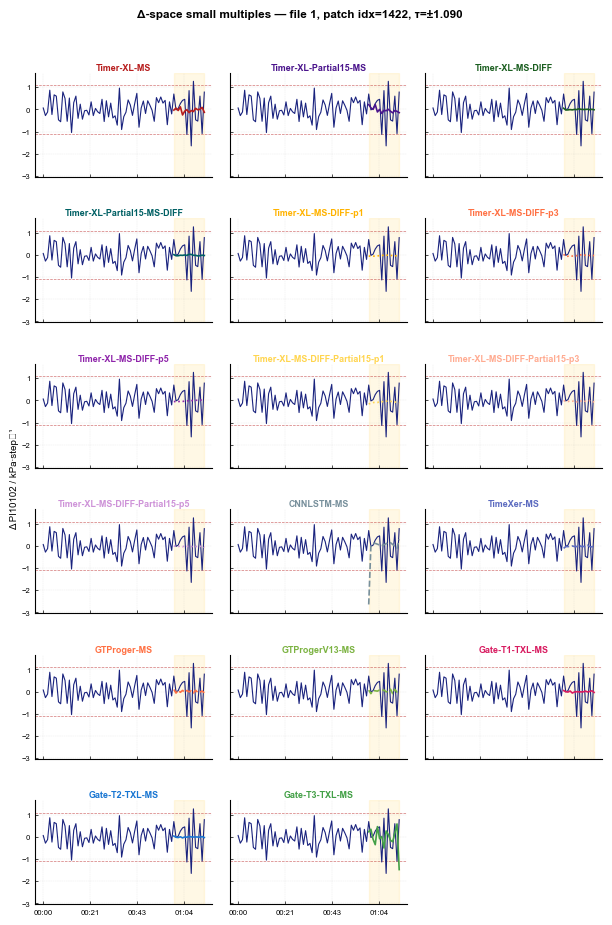

Saved a_small_multiples_diff_file1.png


In [11]:
from matplotlib.ticker import MaxNLocator

display_seq = 60
display_pred = eval_steps
f_focus = 1
seg_lo, seg_hi = file_segs[f_focus]
idx = _pick_with_alarm(f_focus)
if idx - seg_lo < display_seq - 1:
    idx = seg_lo + display_seq - 1
assert idx >= display_seq - 1
true_45 = build_true45_from_patches(dtrue, idx, seq_len=display_seq, pred_len=display_pred)
x_vals = pd.date_range(start='2024-01-01 00:00:00',
                       periods=display_seq + display_pred, freq='min')
hlines = [H_per_file[f_focus], L_per_file[f_focus]]

panel_specs = [
    ('Timer-XL-MS',                  C_TXL_MS,       '-'),
    ('Timer-XL-Partial15-MS',        C_TXL_P15,      '-'),
    ('Timer-XL-MS-DIFF',             C_TXL_DIFF,     '-'),
    ('Timer-XL-Partial15-MS-DIFF',   C_TXL_P15_DIFF, '-'),
    ('Timer-XL-MS-DIFF-p1',          C_P1,           ':'),
    ('Timer-XL-MS-DIFF-p3',          C_P3,           ':'),
    ('Timer-XL-MS-DIFF-p5',          C_P5,           ':'),
    ('Timer-XL-MS-DIFF-Partial15-p1', C_P15P1,       ':'),
    ('Timer-XL-MS-DIFF-Partial15-p3', C_P15P3,       ':'),
    ('Timer-XL-MS-DIFF-Partial15-p5', C_P15P5,       ':'),
    ('CNNLSTM-MS',                   C_CNNLSTM,      '--'),
    ('TimeXer-MS',                   C_TIMEXER,      '--'),
    ('GTProger-MS',                  C_GTPROGER,     '--'),
    ('GTProgerV13-MS',               C_GTPV13,       '--'),
    ('Gate-T1-TXL-MS',               C_GATE1,        '-'),
    ('Gate-T2-TXL-MS',               C_GATE2,        '-'),
    ('Gate-T3-TXL-MS',               C_GATE3,        '-'),
]
panel_specs = [(n, c, ls) for (n, c, ls) in panel_specs if n in dpred]

ncols = 3
nrows = int(np.ceil(len(panel_specs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16/2.54, 4.0*nrows/2.54),
                          sharex=True, sharey=True)
axes_flat = np.atleast_1d(axes).flatten()

all_v = [np.nanmin(true_45), np.nanmax(true_45)] + list(hlines)
for n, *_ in panel_specs:
    p = build_pred45_from_patch(dpred[n], idx, display_seq, display_pred)
    all_v += [np.nanmin(p[display_seq:]), np.nanmax(p[display_seq:])]
g_min, g_max = float(min(all_v)), float(max(all_v))
g_pad = (g_max - g_min) * 0.10
g_ylim = (g_min - g_pad, g_max + g_pad)

for i, (name, color, ls) in enumerate(panel_specs):
    ax = axes_flat[i]
    pred_45 = build_pred45_from_patch(dpred[name], idx, display_seq, display_pred)
    ax.plot(x_vals, true_45, color='#1A237E', linewidth=0.8, zorder=5)
    ax.plot(x_vals, pred_45, color=color, linestyle=ls, linewidth=1.2, zorder=6)
    ax.axvspan(x_vals[display_seq], x_vals[-1], alpha=0.10, color='#FFC107', zorder=0)
    for h in hlines:
        ax.axhline(h, color='#B71C1C', linestyle='--', linewidth=0.5, alpha=0.6, zorder=1)
    ax.set_title(name, fontsize=6.5, fontweight='bold', pad=2, color=color)
    ax.set_ylim(g_ylim)
    ax.tick_params(axis='both', labelsize=5.5, direction='in', length=2, width=0.5)
    ax.grid(True, linewidth=0.3, alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))

for j in range(len(panel_specs), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(f'Δ-space small multiples — file {f_focus}, patch idx={idx}, τ=±{tau_per_file[f_focus]:.3f}',
             fontsize=8.5, fontweight='bold', y=0.997)
fig.text(0.04, 0.5, 'Δ PI10102 / kPa·step⁻¹', va='center', rotation='vertical', fontsize=7)
plt.subplots_adjust(left=0.08, right=0.98, top=0.93, bottom=0.05, hspace=0.4, wspace=0.1)
fig.savefig(f'a_small_multiples_diff_file{f_focus}.png', dpi=300, facecolor='white')
plt.show()
print(f'Saved a_small_multiples_diff_file{f_focus}.png')

## 10. Per-window Δ-MSE / alarm-hit summary table

Quick numeric sanity check next to the figures: per-model Δ-space MSE plus
the per-file ±τ alarm counts, computed in-notebook so you can compare to
`summary.csv`.

In [12]:
H_w = H_per_file[file_idx_aligned][:, None]
L_w = L_per_file[file_idx_aligned][:, None]
true_alarm_patch = ((dtrue > H_w) | (dtrue < L_w)).any(axis=1)

rows = []
for name, arr in dpred.items():
    pred_alarm_patch = ((arr > H_w) | (arr < L_w)).any(axis=1)
    mse_d = float(np.mean((arr - dtrue) ** 2))
    tp = int(np.sum(pred_alarm_patch & true_alarm_patch))
    fp = int(np.sum(pred_alarm_patch & ~true_alarm_patch))
    fn = int(np.sum(~pred_alarm_patch & true_alarm_patch))
    tn = int(np.sum(~pred_alarm_patch & ~true_alarm_patch))
    rows.append(dict(model=name, mse_diff=mse_d,
                     n_pred_alarm=int(pred_alarm_patch.sum()),
                     tp=tp, fp=fp, fn=fn, tn=tn))
summary = pd.DataFrame(rows).set_index('model').sort_values('mse_diff')
print(f'n_true_alarm = {int(true_alarm_patch.sum())} / {len(true_alarm_patch)}')
summary

n_true_alarm = 1852 / 3686


,mse_diff,n_pred_alarm,tp,fp,fn,tn
model,,,,,,
Timer-XL-MS-DIFF-Partial15-p5,0.309064,0,0,0,1852,1834
Timer-XL-Partial15-MS-DIFF,0.309149,36,0,36,1852,1798
Timer-XL-MS-DIFF-p5,0.309311,0,0,0,1852,1834
Timer-XL-MS-DIFF,0.309370,19,0,19,1852,1815
Timer-XL-MS-DIFF-Partial15-p3,0.309491,0,0,0,1852,1834
Gate-T2-TXL-MS,0.310230,19,0,19,1852,1815
Timer-XL-MS-DIFF-p3,0.310289,0,0,0,1852,1834
Timer-XL-MS-DIFF-p1,0.310549,0,0,0,1852,1834
Gate-T1-TXL-MS,0.310832,20,0,20,1852,1814
